In [1]:
from igng import IGNG
import numpy as np
import matplotlib.pyplot as plt
import visualization
import torch
import torchvision

In [2]:
# =========================================================
# TRANSFORMS
# =========================================================

transform = torchvision.transforms.Compose([

    torchvision.transforms.GaussianBlur(3),

    torchvision.transforms.Resize((14, 14)),

    torchvision.transforms.ToTensor(),

    torchvision.transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


# =========================================================
# DATASETS
# =========================================================

training_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testing_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


# =========================================================
# DATALOADERS
# =========================================================

training_dataloader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size=10000,
    shuffle=True
)

testing_dataloader = torch.utils.data.DataLoader(
    testing_dataset,
    batch_size=10000,
    shuffle=False
)


# =========================================================
# MODEL
# =========================================================

model = IGNG(

    input_dim=14 * 14,

    sigma=6.260161, age_max=41, eps_b=0.045996, eps_n=0.002598, mature_age= 12, max_nodes=183,

    device="cpu"
)


# =========================================================
# TRAINING
# =========================================================

print("Training IGNG...")

for images, labels in training_dataloader:

    images = images.view(images.shape[0], -1)

    model.partial_fit(images)

print("Training complete.")


# =========================================================
# SAVE
# =========================================================

model.save("igng.pth")

IGNG initialized on cpu
Training IGNG...
Training complete.


# Visualisation

In [3]:
# =====================================
# Préparer données MNIST pour visualisation
# =====================================

X_train = []
y_train = []

for images, labels in training_dataloader:

    X_train.append(images)
    y_train.append(labels)


X_train = torch.cat(X_train)
y_train = torch.cat(y_train)


# Flatten comme pour IGNG
X_train = X_train.view(
    X_train.shape[0],
    -1
)

In [4]:
vis = visualization.IGNGVisualization(
    igng=model,
    node_size=80,
    edge_width=0.8,
    edge_alpha=0.4
)

# couleurs classes MNIST
vis.set_data_labels(y_train)

🛈 Visualization on CPU


⏲ t-SNE...


c:\Users\Client\Documents\stage_L3_IGNG\visualization.py:208: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(


✓ Saved visualization: IGNG_MNIST_TSNE_3d.png


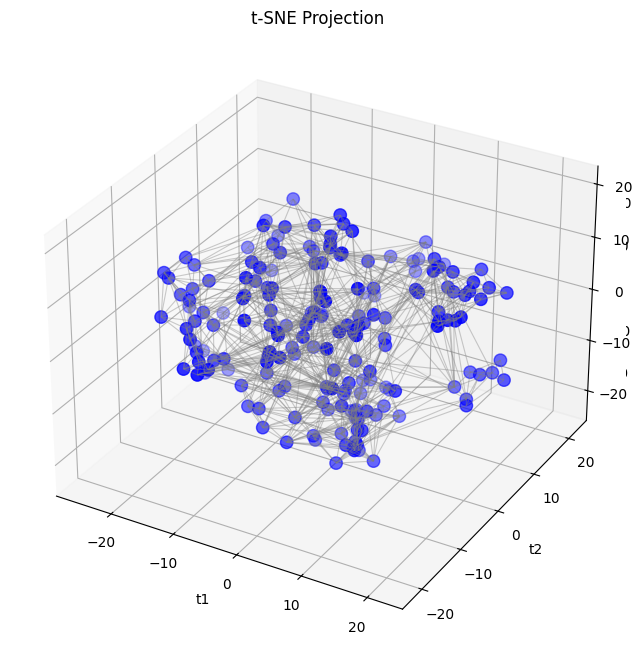

In [5]:
# =====================================
# Visualisation t-SNE
# =====================================

# t-SNE
vis.tsne(
    data=X_train,
    third_dim=True,
    max_points=5000,
    save_path="IGNG_MNIST_TSNE_3d.png"
)

⏲ UMAP...


c:\Users\Client\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Client\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Client\Documents\stage_L3_IGNG\visualization.py:208: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(


✓ Saved visualization: IGNG_MNIST_UMAP_3d.png


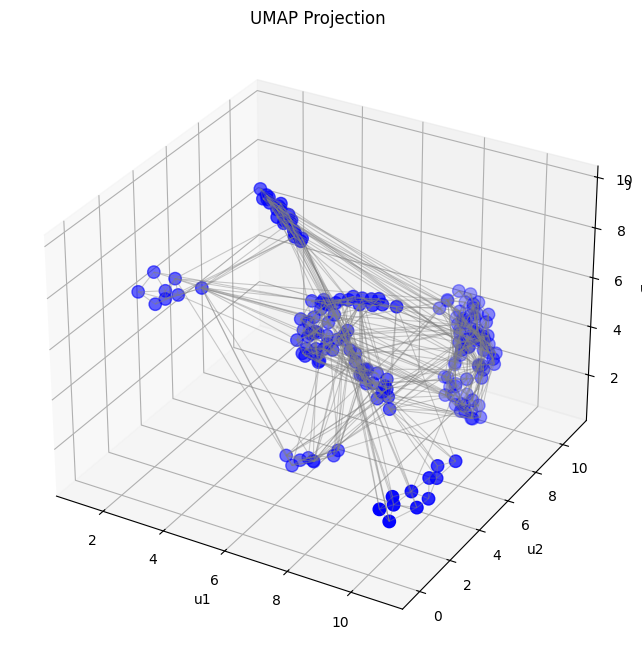

In [6]:
# UMAP
vis.umap(
    data=X_train,
    third_dim=True,
    max_points=5000,
    save_path="IGNG_MNIST_UMAP_3d.png"
)

⏲ PCA...
✓ Saved visualization: IGNG_MNIST_PCA_3d.png


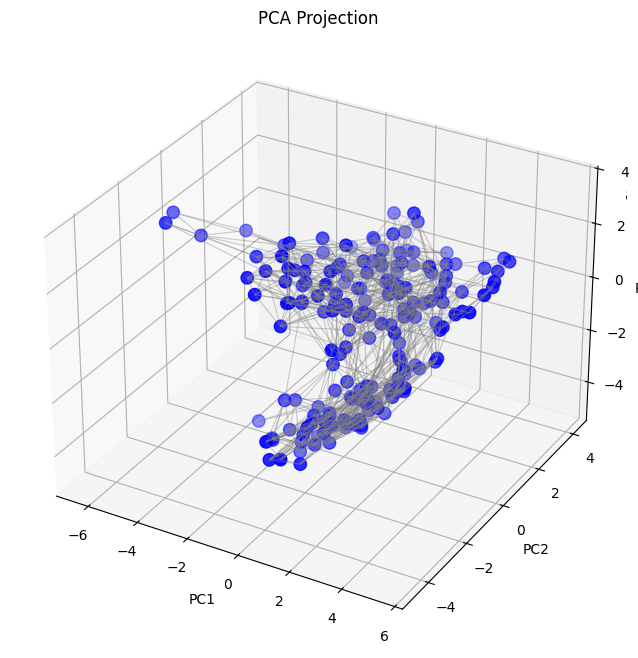

In [7]:
# PCA
vis.pca(
    data=X_train,
    third_dim=True,
    max_points=5000,
    save_path="IGNG_MNIST_PCA_3d.png"
)